In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import cantera as ct

In [3]:
# parameter values
p = 0.05 * ct.one_atm  # pressure
T_in = 373.0  # inlet temperature
mdot_reactants = 0.12  # kg/m^2/s
mdot_products = 0.06  # kg/m^2/s
rxnmech = 'h2o2.yaml'  # reaction mechanism file
comp = 'H2:1.6, O2:1, AR:7'  # premixed gas composition

width = 0.2  # m
loglevel = 1  # amount of diagnostic output (0 to 5)

# Set up the problem
gas = ct.Solution(rxnmech)


In [4]:
# set state to that of the unburned gas at the burner
gas.TPX = T_in, p, comp

# Create the flame simulation object
sim = ct.CounterflowPremixedFlame(gas=gas, width=width)

# Set grid refinement parameters
sim.set_refine_criteria(ratio=3, slope=0.1, curve=0.2, prune=0.02)

# set the boundary flow rates
sim.reactants.mdot = mdot_reactants
sim.products.mdot = mdot_products

sim.set_initial_guess()  # assume adiabatic equilibrium products
sim.show()




>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> reactants <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

    Mass Flux:         0.12 kg/m^2/s 
    Temperature:        373 K 
    Mass Fractions: 
                      H2     0.01024 
                      O2      0.1016 
                      AR      0.8881 



>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> flame <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

    Pressure:        5066 Pa

-------------------------------------------------------------------------------
          z    velocity  spread_rate           T      lambda      eField 
-------------------------------------------------------------------------------
          0        2.24           0         373      -50.19           0 
       0.06     -0.1336        17.8         373      -50.19           0 
        0.1      -1.716       29.67        1214      -50.19           0 
       0.14      -3.298        35.6        2055      -50.19           0 
        0.2      -5.671           0        2055      -50.19           0 

-------

In [5]:
sim.solve(loglevel, auto=True)

# Write the velocity, temperature, and mole fractions to a CSV file
# csv_path = output_dir / "premixed_counterflow_flame_CH4.csv"
# sim.save(csv_path, basis="mole", overwrite=True)

sim.show_stats()
sim.show() # Show final solution profile summary


************ Solving on 5 point grid with energy equation enabled ************

..............................................................................

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 1.602e-05  log(ss)= 4.603     

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 0.0001825  log(ss)= 4.946     

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 0.004676   log(ss)= 3.97      

Attempt Newton solution of steady-state problem.
Newton steady-state solve failed.

Attempt 10 timesteps.
Final timestep info: dt= 0.0799     log(ss)= 1.877     

Attempt Newton solution of steady-state problem.
Newton steady-state solve succeeded.

Problem solved on [5] point grid(s).

..............................................................

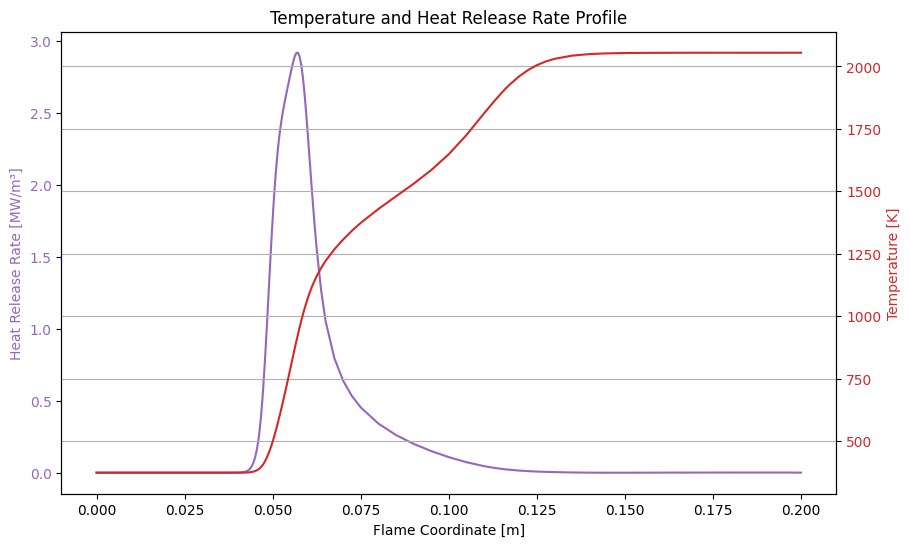

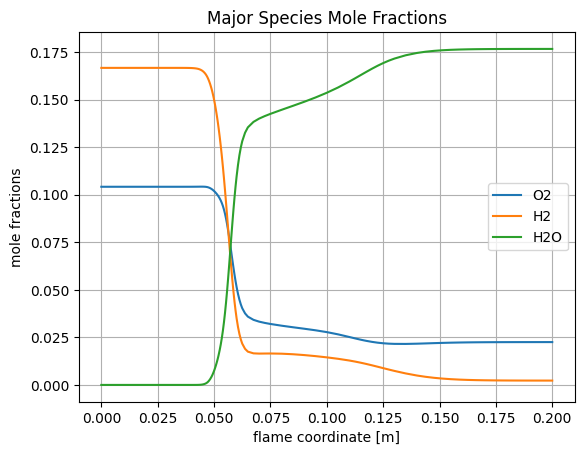

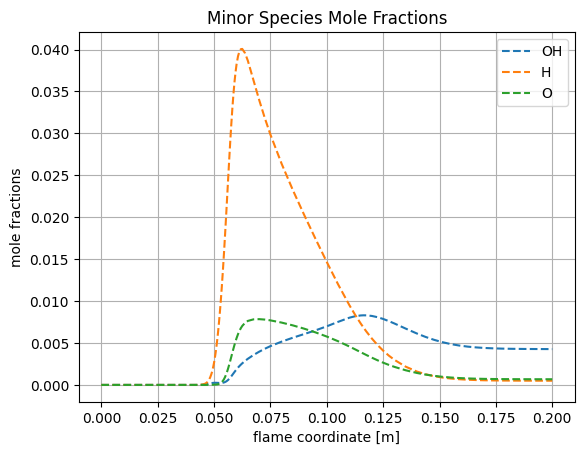

In [ ]:

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(sim.grid, sim.heat_release_rate / 1e6, color='C4')
ax1.set_ylabel('Heat Release Rate [MW/m³]', color='C4')
ax1.tick_params(axis='y', labelcolor='C4')
ax1.set_xlabel('Flame Coordinate [m]')

ax2 = ax1.twinx() # Create a second y-axis sharing the same x-axis
ax2.plot(sim.grid, sim.T, color='C3')
ax2.set_ylabel('Temperature [K]', color='C3')
ax2.tick_params(axis='y', labelcolor='C3')

plt.title('Temperature and Heat Release Rate Profile')
plt.grid(True)
plt.show()

fig, ax = plt.subplots()
major = ('O2', 'H2', 'H2O')
states = sim.to_array()
ax.plot(states.grid, states(*major).X, label=major)
ax.set(xlabel='flame coordinate [m]', ylabel='mole fractions')
ax.set_title('Major Species Mole Fractions')
ax.legend()
plt.grid(True)
plt.show()

fig, ax = plt.subplots()
minor = ('OH', 'H', 'O')
ax.plot(states.grid, states(*minor).X, label=minor, linestyle='--')
ax.set(xlabel='flame coordinate [m]', ylabel='mole fractions', )
ax.set_title('Minor Species Mole Fractions')
ax.legend()
plt.grid(True)
plt.show()